# Klasifikasi Citra Aksara Jawa Menggunakan Metode Convolutional Neural Network (CNN)

## Fariz Saputra (23051030002)

## Import Library

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"D:\ML\UTS\Dataset UTS\dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    r"D:\ML\UTS\Dataset UTS\dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

class_names = train_ds.class_names

Found 4047 files belonging to 20 classes.
Using 3238 files for training.
Found 4047 files belonging to 20 classes.
Using 809 files for validation.


## Informasi Kelas

In [ ]:
print("Jumlah kelas:", len(train_ds.class_names))
print("Nama kelas:", train_ds.class_names)

Jumlah kelas: 20
Nama kelas: ['01-Ha', '02-Na', '03-Ca', '04-Ra', '05-Ka', '06-Da', '07-Ta', '08-Sa', '09-Wa', '10-La', '11-Pa', '12-Dha', '13-Ja', '14-Ya', '15-Nya', '16-Ma', '17-Ga', '18-Ba', '19-Tha', '20-Nga']


## Normalisasi Data

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

## Optimasi Dataset

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Augmantation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.03),
])

## Model CNN

In [ ]:
model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(20, activation='softmax')
])

c:\Users\VICTUS\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)

## Training Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.0500 - loss: 2.9992 - val_accuracy: 0.0878 - val_loss: 2.9810
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.1587 - loss: 2.7496 - val_accuracy: 0.4017 - val_loss: 2.1470
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3027 - loss: 2.3088 - val_accuracy: 0.4722 - val_loss: 1.7803
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3820 - loss: 1.9759 - val_accuracy: 0.6082 - val_loss: 1.2463
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5037 - loss: 1.5676 - val_accuracy: 0.6984 - val_loss: 0.9606
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5710 - loss: 1.3200 - val_accuracy: 0.7614 - val_loss: 0.7574
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6238 - loss: 1.1462 - val_accuracy: 0.8146 - val_loss: 0.6061
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6587 - loss: 1.0175 - val_acc

## Garafik Akurasi 

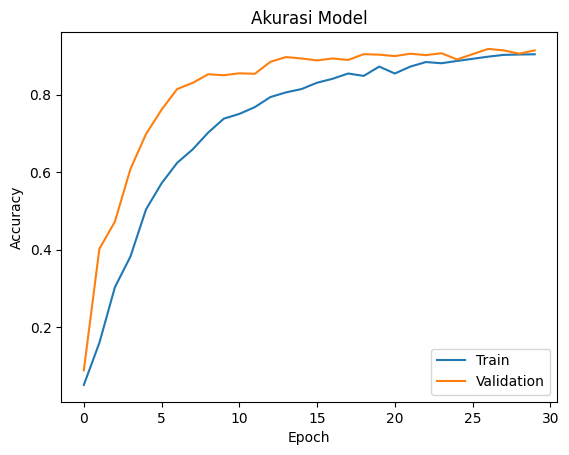

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Grafik Loss

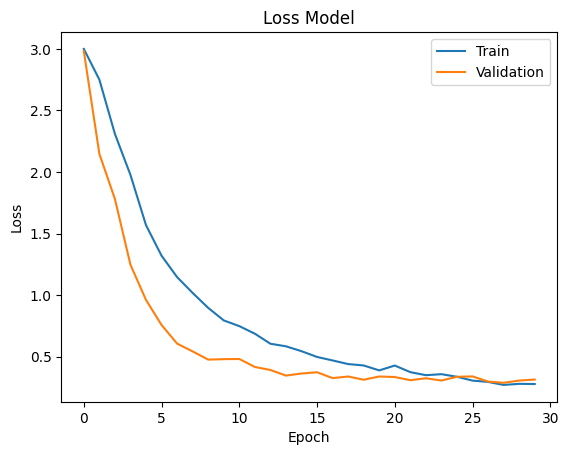

In [ ]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


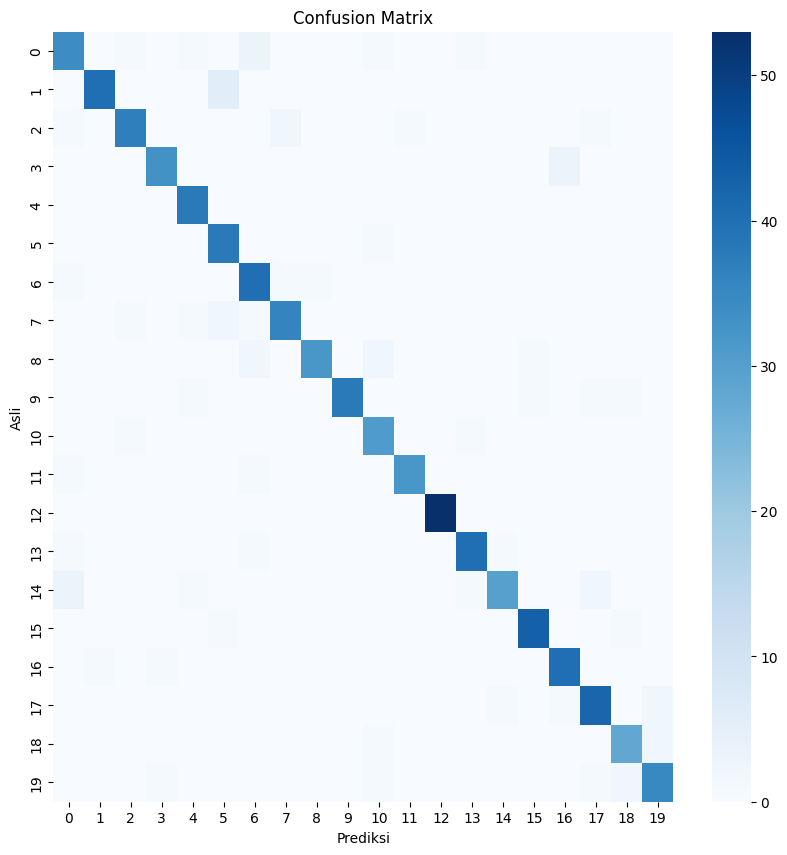

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    pred = model.predict(images)
    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Asli")
plt.show()

## Akurasi

In [ ]:
print("Akurasi training terakhir:", history.history['accuracy'][-1])
print("Akurasi validasi terakhir:", history.history['val_accuracy'][-1])

Akurasi training terakhir: 0.9045706987380981
Akurasi validasi terakhir: 0.9147095084190369


## Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       01-Ha       0.83      0.83      0.83        41
       02-Na       0.98      0.87      0.92        46
       03-Ca       0.93      0.88      0.90        42
       04-Ra       0.94      0.92      0.93        36
       05-Ka       0.90      1.00      0.95        38
       06-Da       0.81      0.97      0.88        39
       07-Ta       0.83      0.93      0.88        43
       08-Sa       0.92      0.88      0.90        41
       09-Wa       0.97      0.86      0.91        37
       10-La       1.00      0.90      0.95        42
       11-Pa       0.84      0.94      0.89        33
      12-Dha       0.97      0.94      0.96        34
       13-Ja       1.00      1.00      1.00        53
       14-Ya       0.93      0.93      0.93        43
      15-Nya       0.94      0.81      0.87        37
       16-Ma       0.96      0.96      0.96        45
       17-Ga       0.91      0.95      0.93        42
       18-Ba       0.89    

## Prediksi Gambar 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


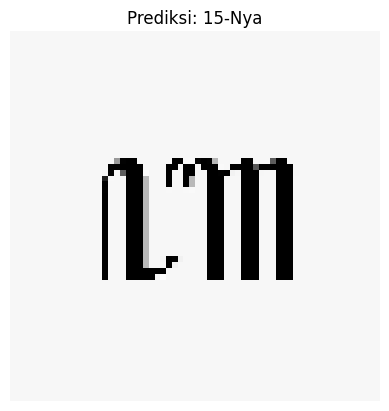

Hasil prediksi: 15-Nya


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

nama_file = "Aksara Jawa (13).jpg"
base_path = r"D:\ML\UTS\Dataset UTS\Test"
img_path = os.path.join(base_path, nama_file)
img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img)/255.0
img_input = np.expand_dims(img_array, axis=0)

pred = model.predict(img_input)
hasil = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Prediksi: {hasil}")
plt.axis("off")
plt.show()

print(f"Hasil prediksi: {hasil}")

## Hasil Akhir 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


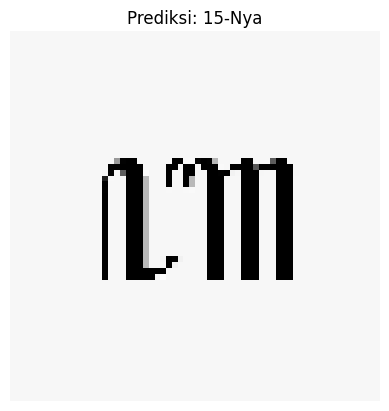

In [ ]:
img = image.load_img(img_path, target_size=(64,64))
img_array = image.img_to_array(img)/255.0

# buat display (tanpa normalisasi)
img_display = image.img_to_array(img).astype("uint8")

img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

hasil = class_names[np.argmax(pred)]

plt.imshow(img_display) 
plt.title(f"Prediksi: {hasil}")
plt.axis("off")
plt.show()